# Nama : Muhamad Farrel Dava Fauzan

# Pemahaman Masalah

## Konteks Data

Dataset ini berisi data karyawan dari sebuah perusahaan yang mencakup informasi demografis, pekerjaan, pendapatan, pengalaman kerja, serta tingkat kepuasan karyawan. Setiap baris merepresentasikan satu karyawan dengan berbagai informasi seperti:

* Usia karyawan (Age)
* Tingkat pendidikan (Education)
* Departemen dan jabatan (Department, JobRole)
* Pendapatan bulanan (MonthlyIncome)
* Lama bekerja di perusahaan (YearsAtCompany)
* Status lembur (OverTime)
* Tingkat kepuasan kerja (JobSatisfaction)
* Work-Life Balance
* Status karyawan (Attrition atau Non-Attrition)

Attrition menjadi perhatian penting karena tingginya tingkat karyawan yang keluar dapat meningkatkan biaya rekrutmen dan pelatihan, mengurangi produktivitas perusahaan, serta menyebabkan hilangnya sumber daya manusia yang berpengalaman. Dengan memahami faktor-faktor yang berkaitan dengan attrition, perusahaan dapat menyusun strategi retensi karyawan yang lebih efektif.

---

## Tujuan Analisis

Analisis ini bertujuan untuk:

Memahami karakteristik karyawan secara umum.
Mengidentifikasi faktor-faktor yang berkaitan dengan attrition.
Mengevaluasi kualitas data, termasuk keberadaan outlier.
Membangun model machine learning untuk memprediksi attrition karyawan.
Membandingkan performa **Logistic Regression** dan **Random Forest** dalam memprediksi attrition.


---

## Pertanyaan Analisis

Analisis ini difokuskan untuk menjawab beberapa pertanyaan berikut:

* Bagaimana distribusi karyawan yang mengalami attrition dan yang tidak?
* Apakah terdapat perbedaan usia, pendapatan, dan lama bekerja antara karyawan yang mengalami attrition dan yang tidak?
* Apakah status lembur (OverTime) berkaitan dengan tingkat attrition karyawan?
* Apakah tingkat kepuasan kerja (JobSatisfaction) dan work-life balance memiliki hubungan dengan attrition?
* Jabatan (JobRole) dan departemen (Department) mana yang memiliki tingkat attrition tertinggi?
* Fitur apa saja yang memiliki hubungan signifikan terhadap attrition?
* Model machine learning mana yang memberikan performa terbaik dalam memprediksi attrition?

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score


from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Loading Dataset and Data Understanding

In [ ]:
df_employee = pd.read_csv("https://raw.githubusercontent.com/farrelfz/dataset-ppkd-2026/refs/heads/main/Employee-Attrition.csv")
df_employee.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df_employee.shape

(1470, 35)

In [ ]:
df_employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df_employee.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
df_employee.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
df_employee.duplicated().sum()

np.int64(0)

In [ ]:
df_employee.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


In [ ]:
df_employee['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


# Data Cleaning

In [ ]:
df_clean = df_employee.copy()

drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean.drop(drop_cols, axis=1, inplace=True)

df_clean = df_clean[['Attrition'] + [col for col in df_clean.columns if col != 'Attrition']]

df_clean.head()

,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,Yes,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,No,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,Yes,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,No,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,No,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


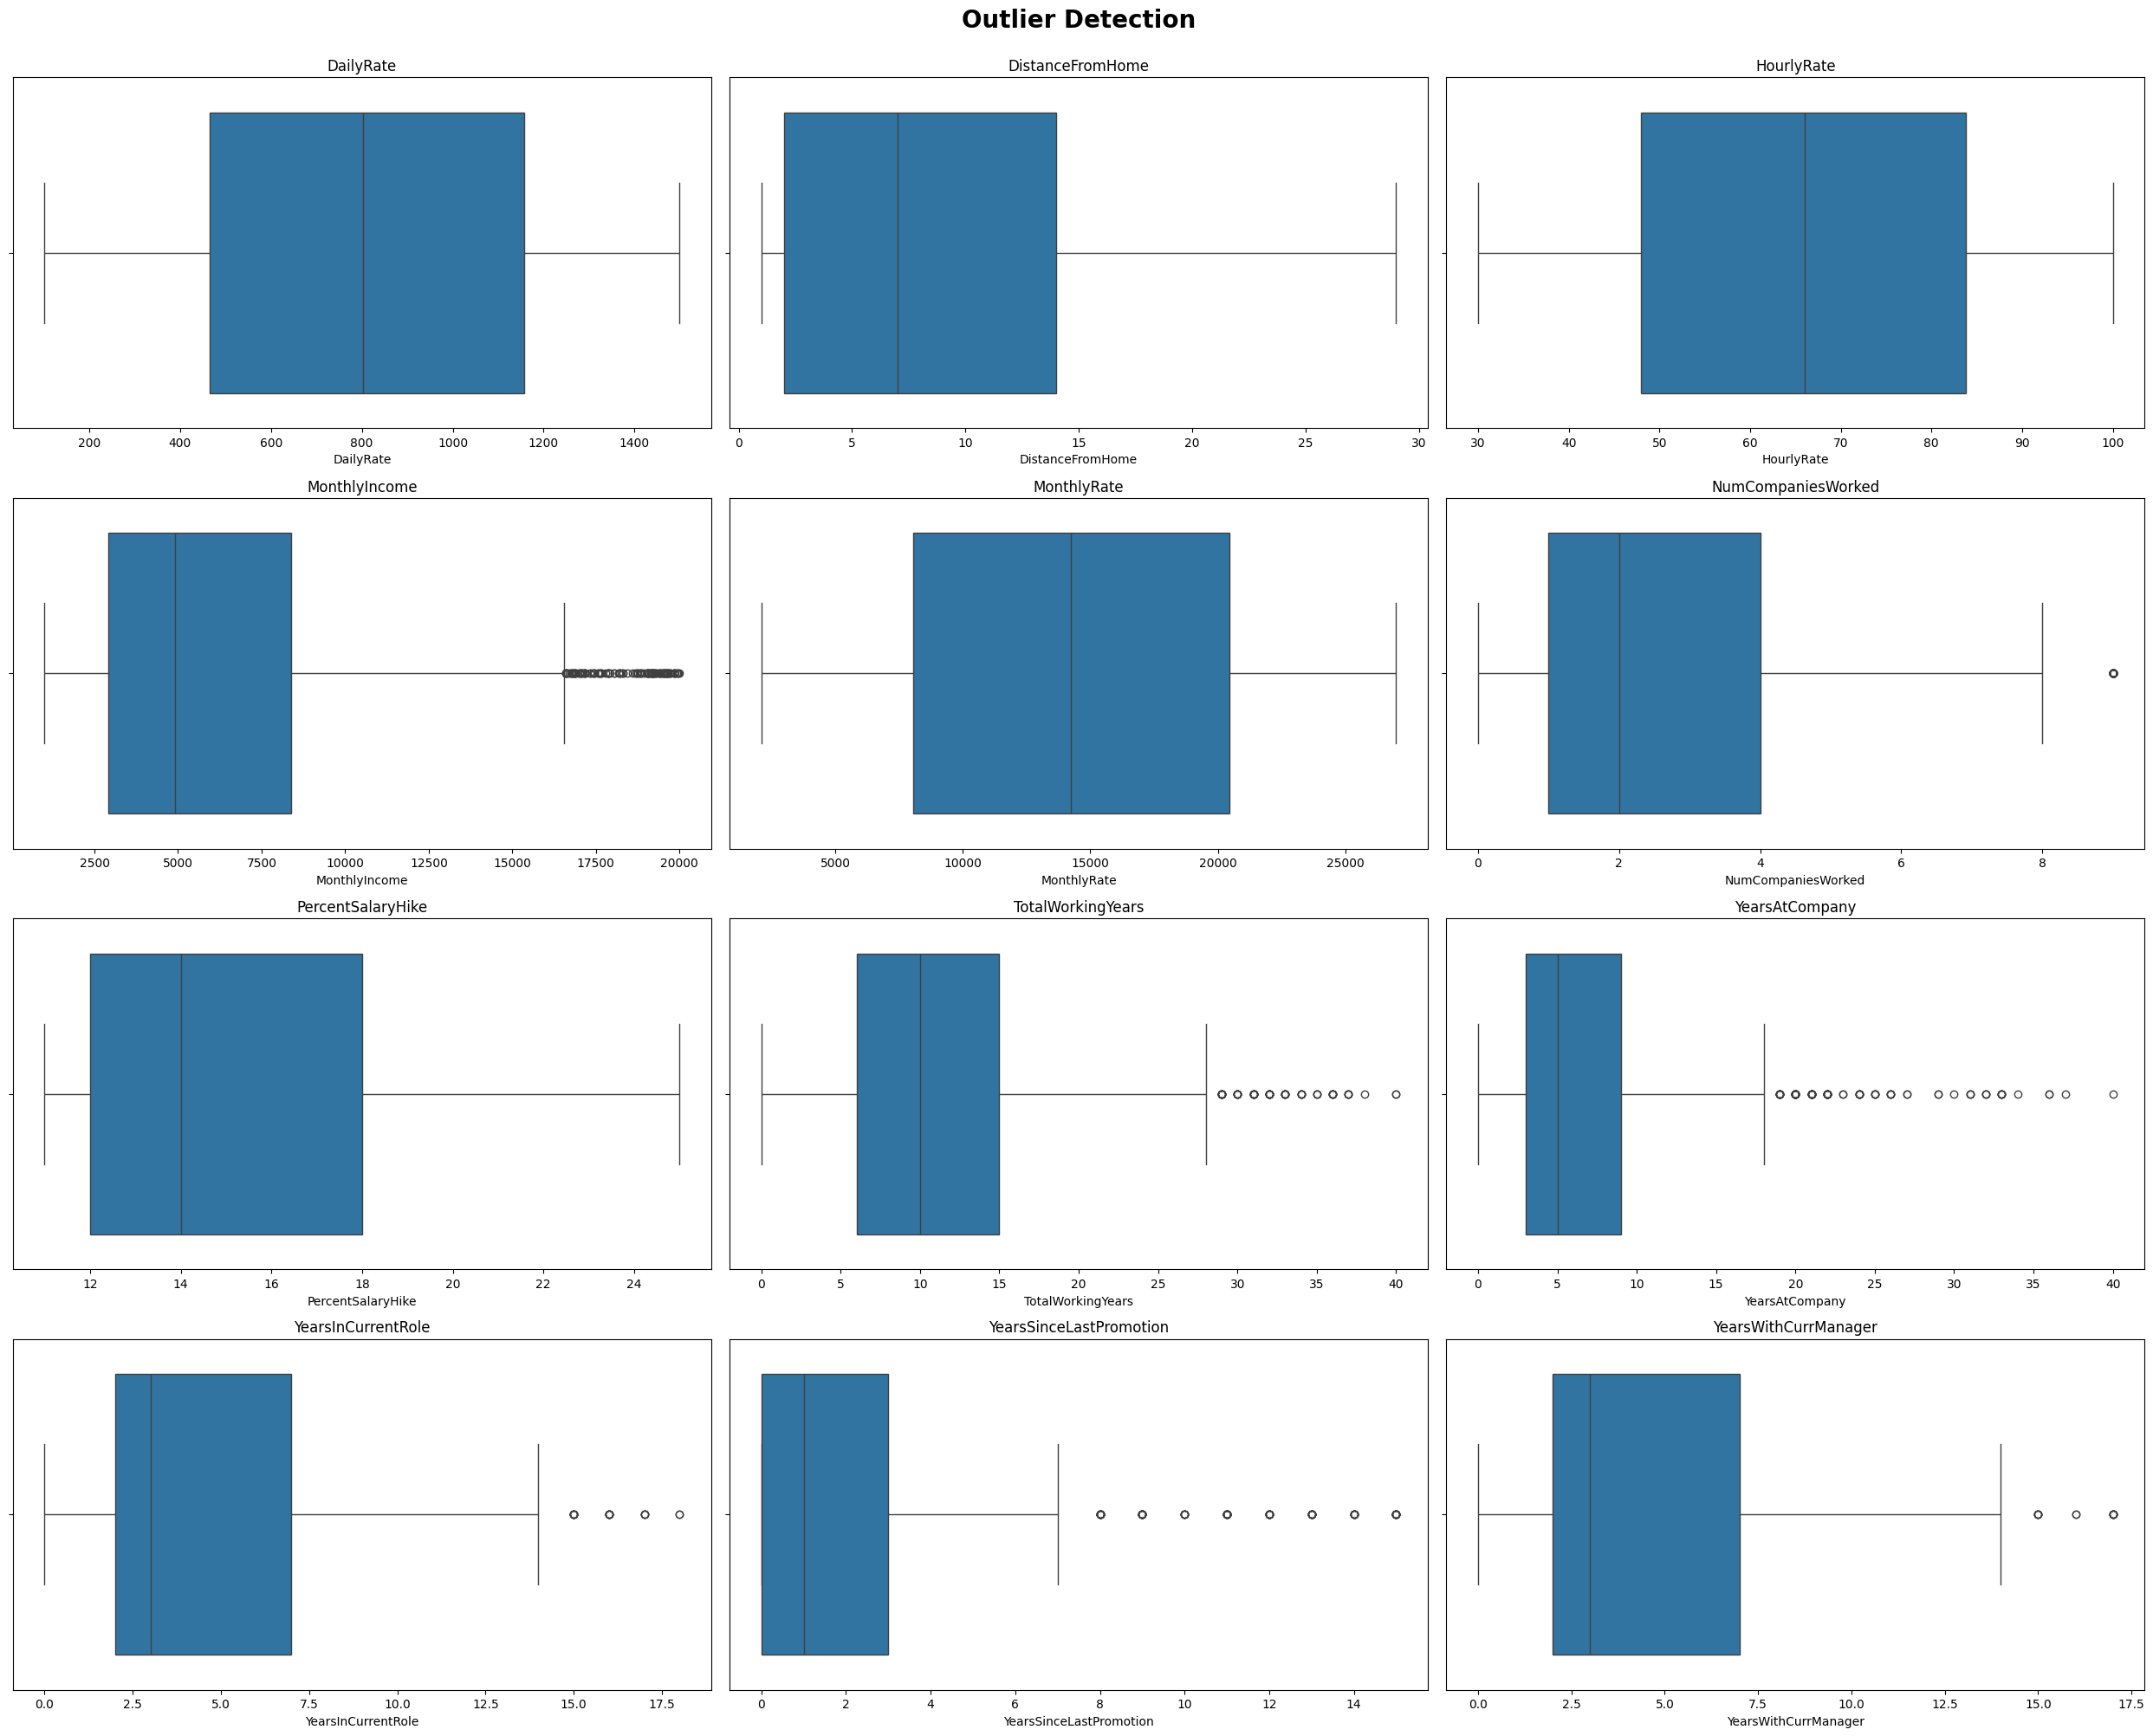

In [ ]:
check_outlier_cols = [
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

plt.figure(figsize=(25,20))

plt.suptitle(
    'Outlier Detection',
    fontsize=20,
    fontweight='bold',
    y=1
)

for i, col in enumerate(check_outlier_cols, 1):
    plt.subplot(4,3,i)
    sns.boxplot(x=df_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Insight:** Meski terdapat Outllier pada kolom MonthlyIncome, NumCompaniesWorked, TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, dan YearsWithCurrManager. Namun, berdasarkan konteks sumber daya manusia, nilai-nilai tersebut masih mencerminkan kondisi yang realistis dan tidak menunjukkan adanya kesalahan pencatatan data. Oleh karena itu, outlier tidak dihapus dan tetap dipertahankan untuk menjaga informasi penting yang dapat membantu proses analisis serta pemodelan machine learning.

# Check P-Value

In [ ]:
# Chi-Square
categorical_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime'
]

chi_results = []

for col in categorical_cols:

    contingency = pd.crosstab(
        df_clean[col],
        df_clean['Attrition']
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    if p < 0.05:
        conclusion = 'Signifikan'
    else:
        conclusion = 'Tidak Signifikan'

    chi_results.append([
        col,
        round(p, 5),
        conclusion
    ])

chi_df = pd.DataFrame(
    chi_results,
    columns=[
        'Feature',
        'P_Value',
        'Kesimpulan'
    ]
)

chi_df

,Feature,P_Value,Kesimpulan
0,BusinessTravel,0.00001,Signifikan
1,Department,0.00453,Signifikan
2,EducationField,0.00677,Signifikan
3,Gender,0.29057,Tidak Signifikan
4,JobRole,0.00000,Signifikan
5,MaritalStatus,0.00000,Signifikan
6,OverTime,0.00000,Signifikan


In [ ]:
# Mann-Whitney
numerical_cols = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'Education',
    'EnvironmentSatisfaction',
    'HourlyRate',
    'JobInvolvement',
    'JobLevel',
    'JobSatisfaction',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'WorkLifeBalance',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

mw_results = []

for col in numerical_cols:

    yes_group = df_clean[
        df_clean['Attrition'] == 'Yes'
    ][col]

    no_group = df_clean[
        df_clean['Attrition'] == 'No'
    ][col]

    stat, p = mannwhitneyu(
        yes_group,
        no_group
    )

    if p < 0.05:
        result = 'Signifikan'
    else:
        result = 'Tidak Signifikan'

    mw_results.append(
        [col, p, result]
    )

mw_df = pd.DataFrame(
    mw_results,
    columns=[
        'Feature',
        'P_Value',
        'Kesimpulan'
    ]
)

mw_df

,Feature,P_Value,Kesimpulan
0,Age,5.304342e-11,Signifikan
1,DailyRate,2.900458e-02,Signifikan
2,DistanceFromHome,2.387047e-03,Signifikan
3,Education,2.448310e-01,Tidak Signifikan
4,EnvironmentSatisfaction,2.173049e-04,Signifikan
5,HourlyRate,7.976303e-01,Tidak Signifikan
6,JobInvolvement,4.651927e-06,Signifikan
7,JobLevel,2.956987e-13,Signifikan
8,JobSatisfaction,7.957918e-05,Signifikan
9,MonthlyIncome,2.950831e-14,Signifikan


# Exploratory Data Analysis (EDA)

In [ ]:
df_eda = df_clean.copy()

# Target
df_eda['Attrition'] = df_eda['Attrition'].map({
    'No': 0,
    'Yes': 1
})

# Features
df_eda['Gender'] = df_eda['Gender'].map({
    'Female': 0,
    'Male': 1
})

df_eda['OverTime'] = df_eda['OverTime'].map({
    'No': 0,
    'Yes': 1
})

df_eda['BusinessTravel'] = df_eda['BusinessTravel'].map({
    'Non-Travel': 0,
    'Travel_Rarely': 1,
    'Travel_Frequently': 2
})

df_eda['Department'] = df_eda['Department'].map({
    'Human Resources': 0,
    'Research & Development': 1,
    'Sales': 2
})

df_eda['EducationField'] = df_eda['EducationField'].map({
    'Human Resources': 0,
    'Life Sciences': 1,
    'Marketing': 2,
    'Medical': 3,
    'Technical Degree': 4,
    'Other': 5,

})

df_eda['MaritalStatus'] = df_eda['MaritalStatus'].map({
    'Single': 0,
    'Married': 1,
    'Divorced': 2
})

jobrole_map = {
    'Healthcare Representative': 0,
    'Human Resources': 1,
    'Laboratory Technician': 2,
    'Manager': 3,
    'Manufacturing Director': 4,
    'Research Director': 5,
    'Research Scientist': 6,
    'Sales Executive': 7,
    'Sales Representative': 8
}

df_eda['JobRole'] = df_eda['JobRole'].map(jobrole_map)

df_eda.head()

,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,41,1,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,0,49,2,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,1,37,1,1373,1,2,2,5,4,1,...,3,2,0,7,3,3,0,0,0,0
3,0,33,2,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,0,27,1,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


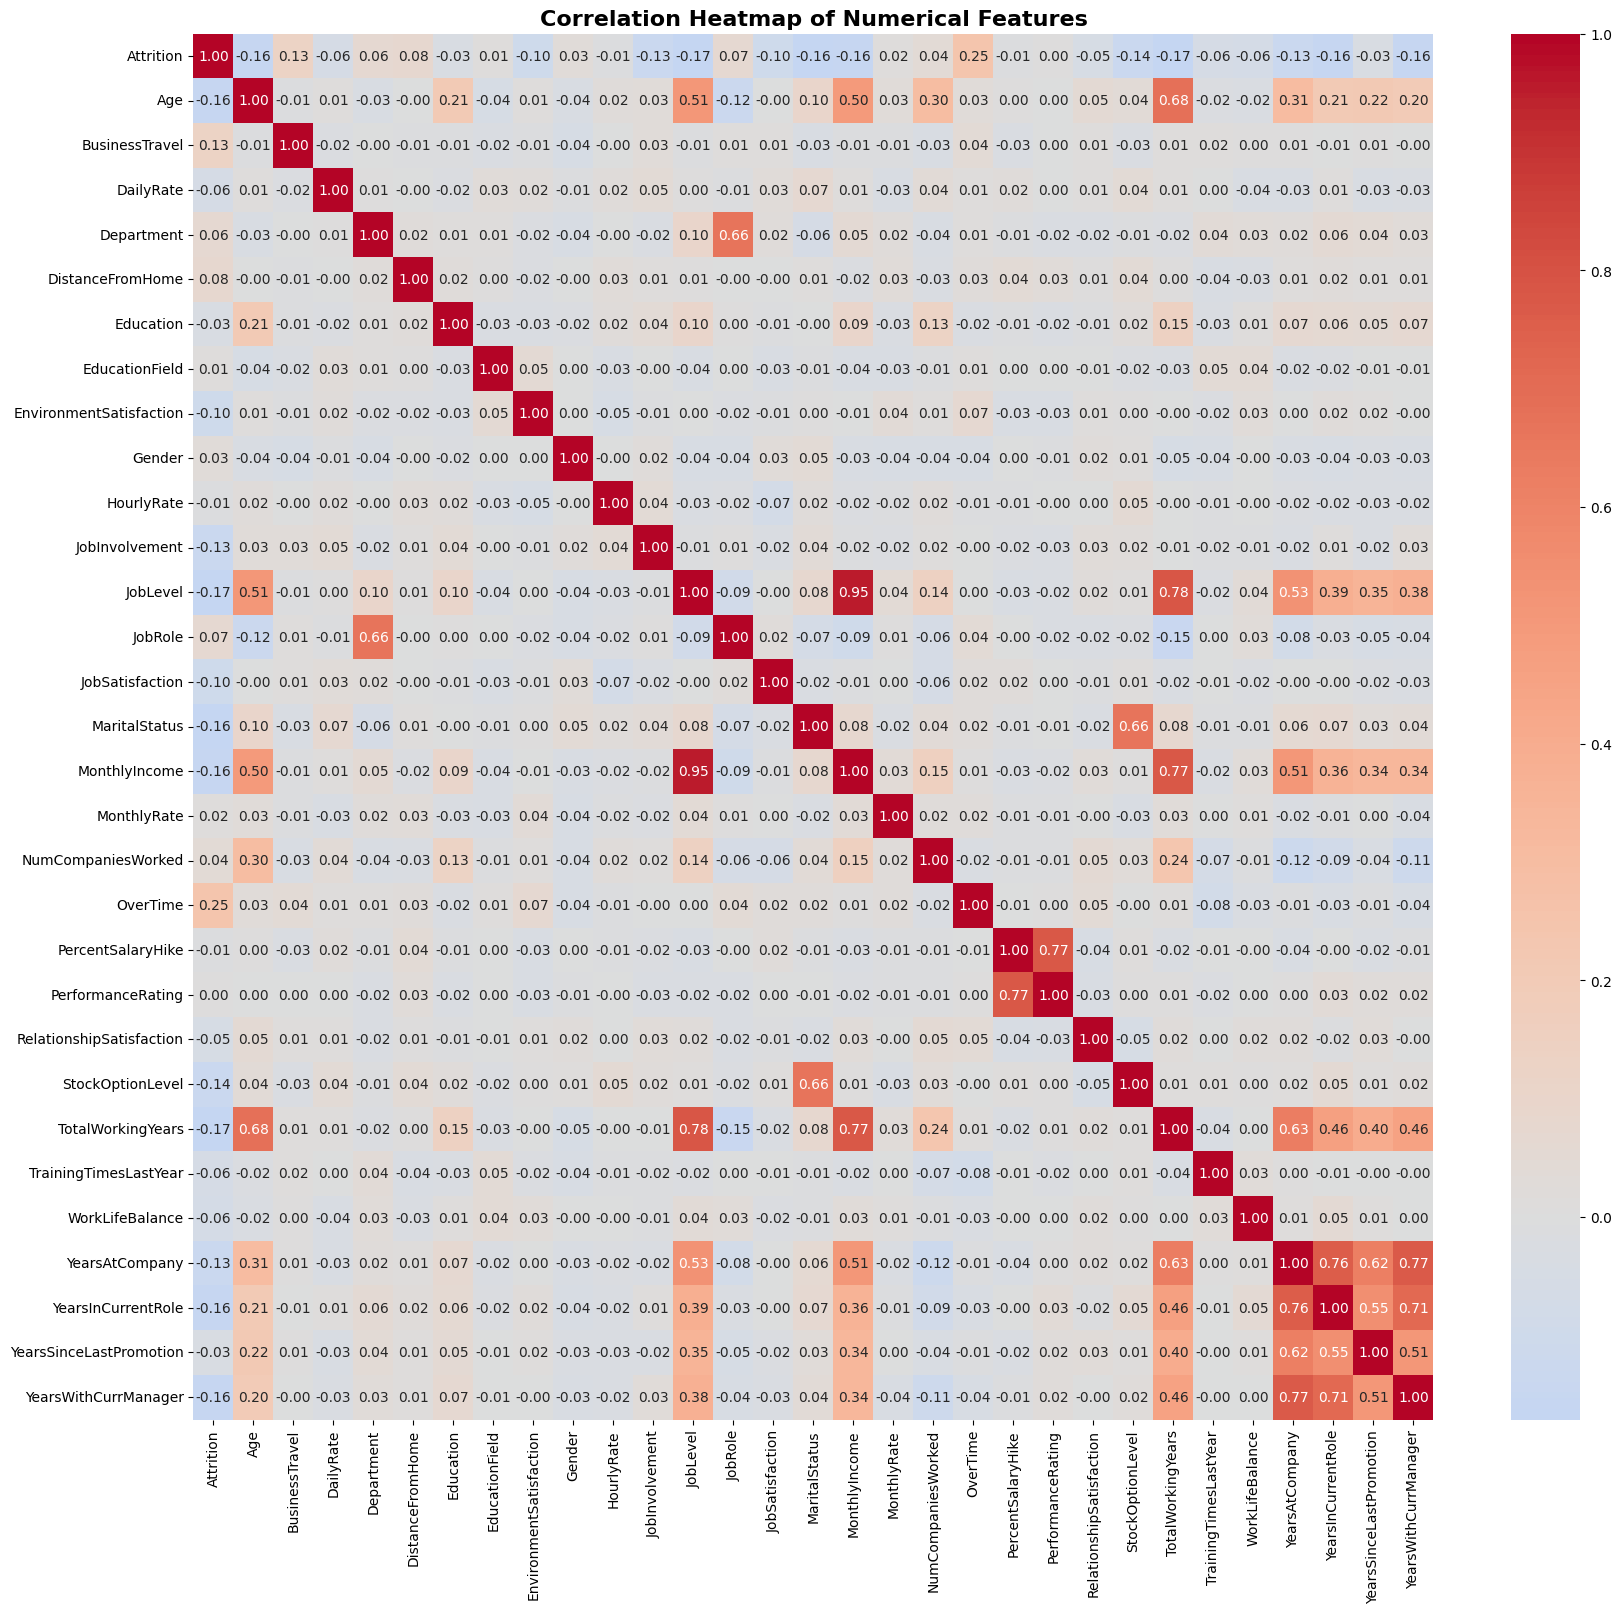

In [ ]:
plt.figure(figsize=(20,18))

sns.heatmap(
    df_eda.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Heatmap of Numerical Features',
    fontsize=16,
    fontweight='bold',
    y=1
)

plt.show()

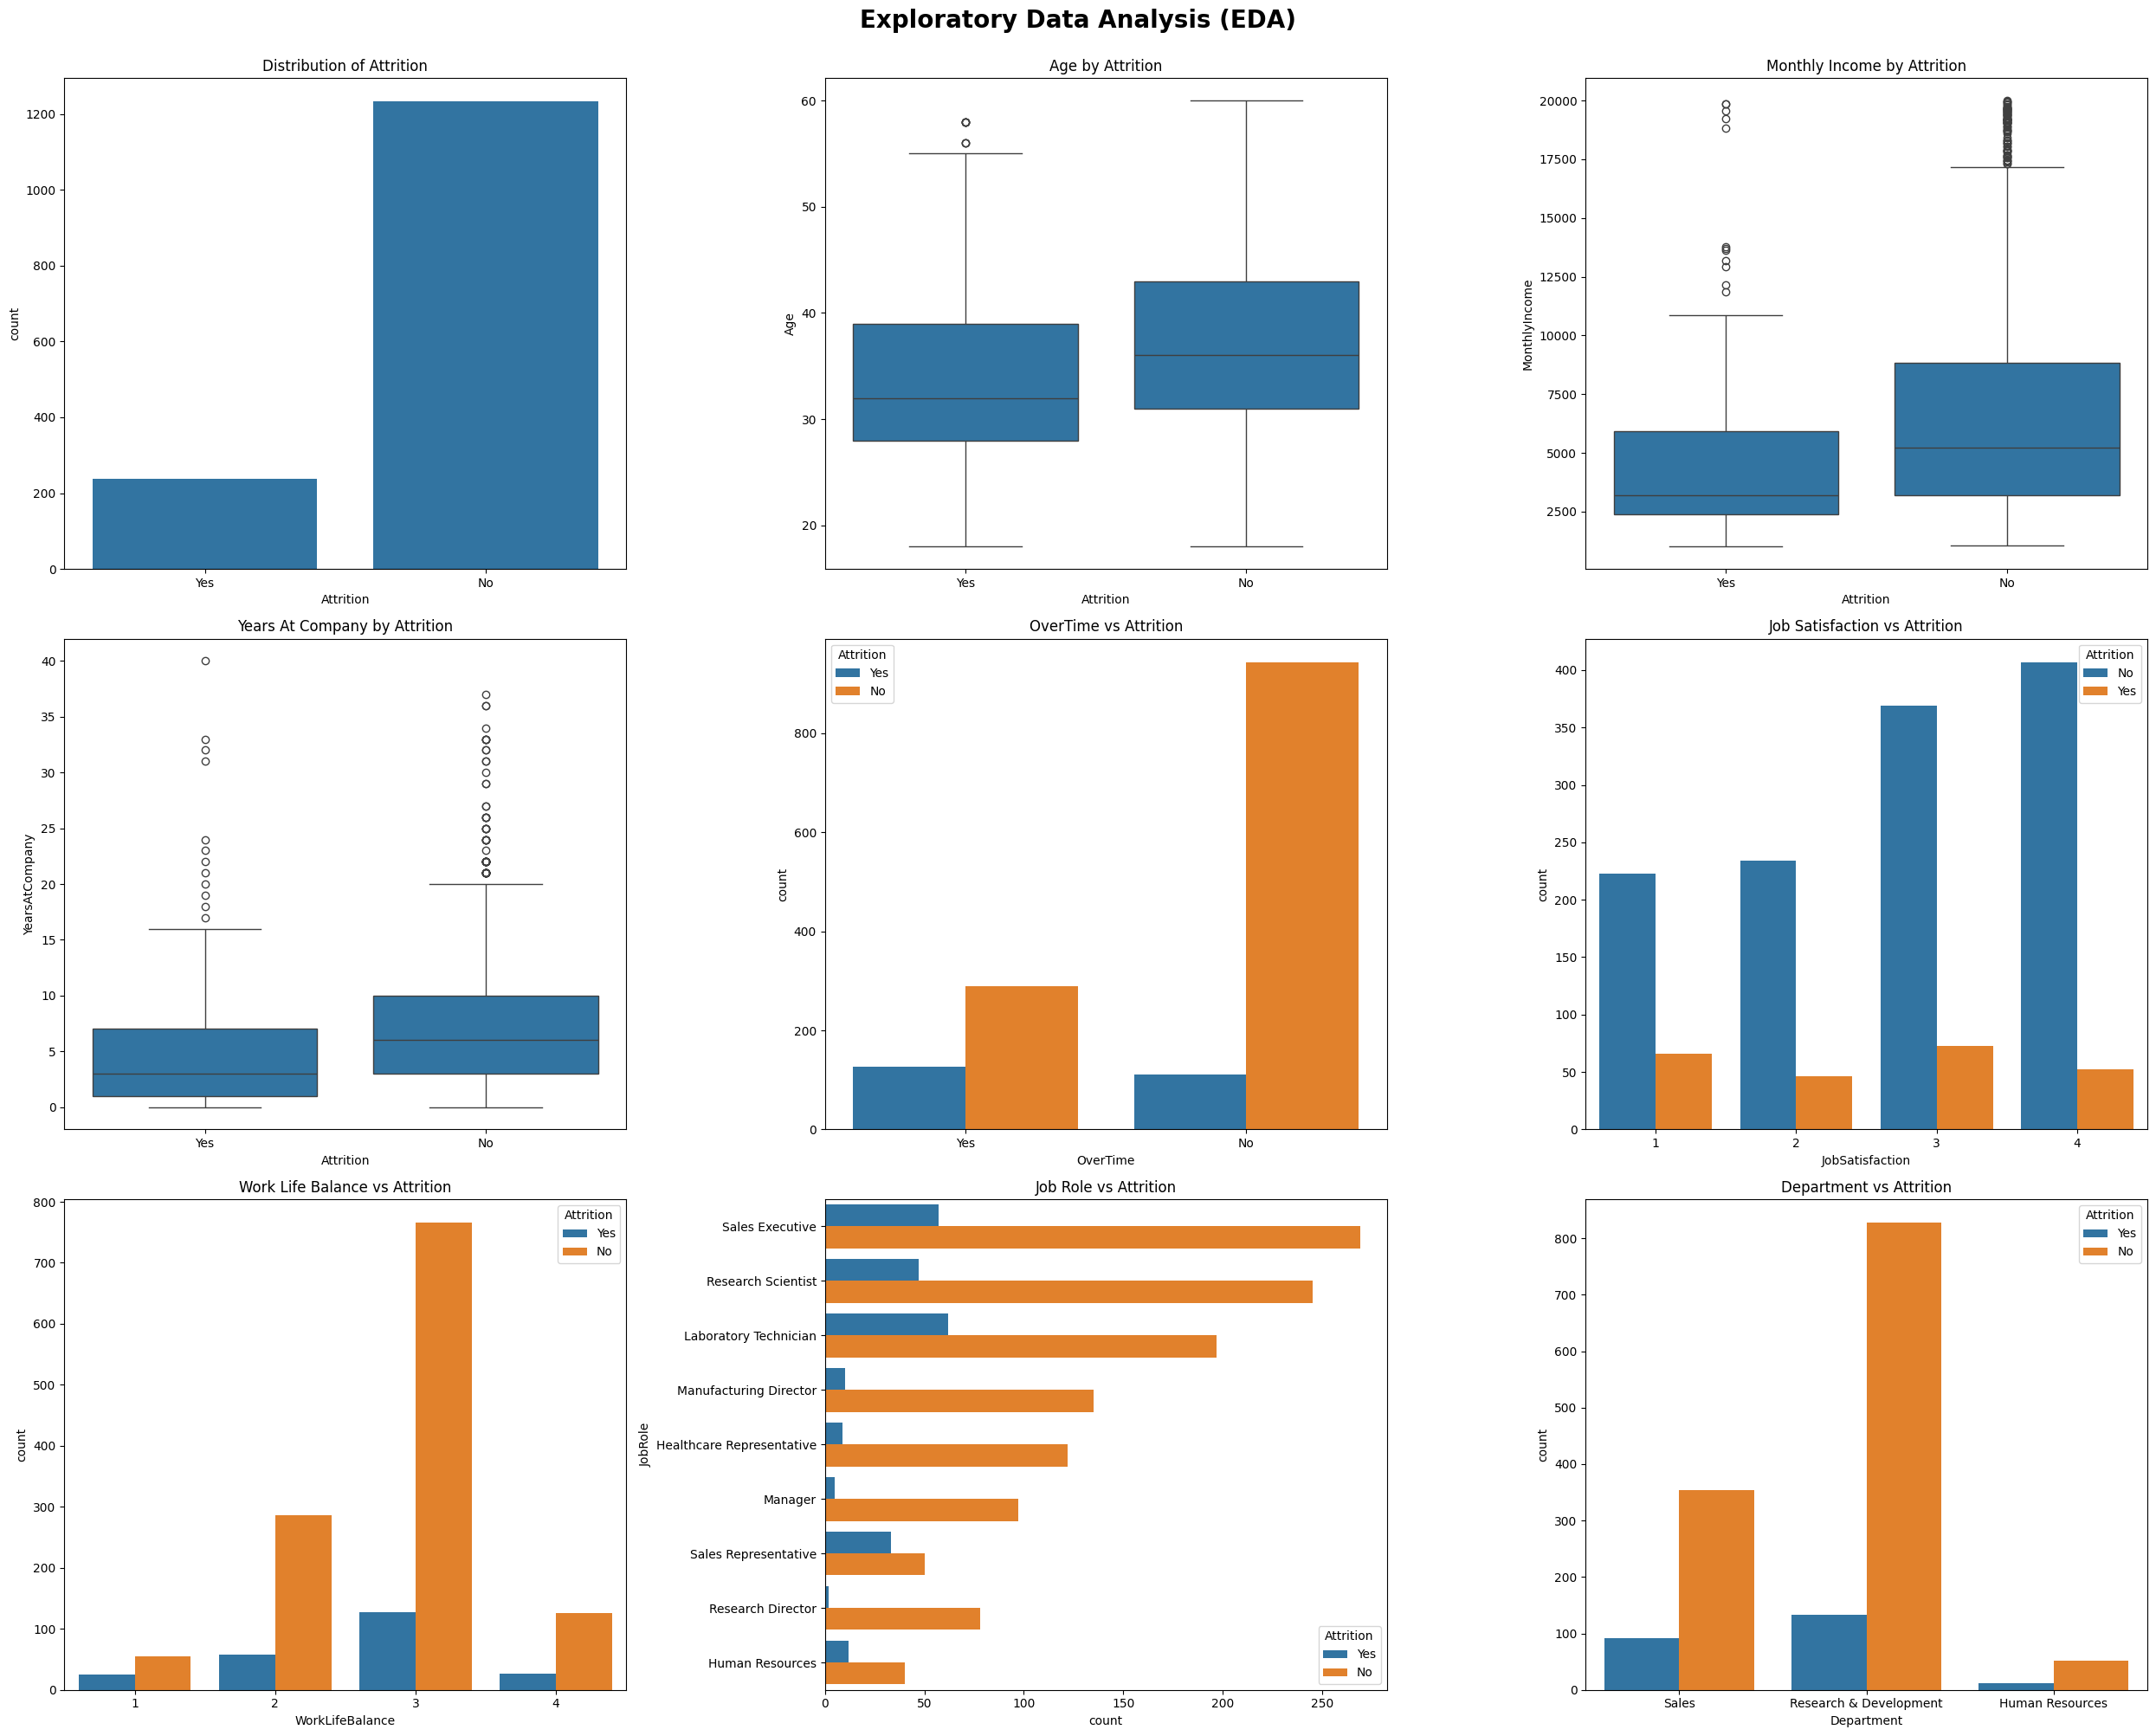

In [ ]:
fig, axes = plt.subplots(
    3, 3,
    figsize=(25, 20)
)

fig.suptitle(
    'Exploratory Data Analysis (EDA)',
    fontsize=20,
    fontweight='bold',
    y=1
)

# 1. Attrition Distribution
sns.countplot(
    x='Attrition',
    data=df_clean,
    ax=axes[0,0]
)
axes[0,0].set_title('Distribution of Attrition')

# 2. Age vs Attrition
sns.boxplot(
    x='Attrition',
    y='Age',
    data=df_clean,
    ax=axes[0,1]
)
axes[0,1].set_title('Age by Attrition')

# 3. MonthlyIncome vs Attrition
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df_clean,
    ax=axes[0,2]
)
axes[0,2].set_title('Monthly Income by Attrition')

# 4. YearsAtCompany vs Attrition
sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df_clean,
    ax=axes[1,0]
)
axes[1,0].set_title('Years At Company by Attrition')

# 5. OverTime vs Attrition
sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df_clean,
    ax=axes[1,1]
)
axes[1,1].set_title('OverTime vs Attrition')

# 6. JobSatisfaction vs Attrition
sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    data=df_clean,
    ax=axes[1,2]
)
axes[1,2].set_title('Job Satisfaction vs Attrition')

# 7. WorkLifeBalance vs Attrition
sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df_clean,
    ax=axes[2,0]
)
axes[2,0].set_title('Work Life Balance vs Attrition')

# 8. JobRole vs Attrition
sns.countplot(
    y='JobRole',
    hue='Attrition',
    data=df_clean,
    ax=axes[2,1]
)
axes[2,1].set_title('Job Role vs Attrition')

# 9. Department vs Attrition
sns.countplot(
    x='Department',
    hue='Attrition',
    data=df_clean,
    ax=axes[2,2]
)
axes[2,2].set_title('Department vs Attrition')

plt.tight_layout()
plt.show()

# Feature Engineering

# VIF Check

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()

vif_df['Feature'] = df_eda.columns

vif_df['VIF'] = [
    variance_inflation_factor(df_eda.values, i)
    for i in range(df_eda.shape[1])
]

vif_df.sort_values(
    by='VIF',
    ascending=False
)

,Feature,VIF
21,PerformanceRating,123.325311
12,JobLevel,52.541571
20,PercentSalaryHike,42.549058
1,Age,33.426715
16,MonthlyIncome,32.042963
26,WorkLifeBalance,15.544803
11,JobInvolvement,15.230747
24,TotalWorkingYears,14.657628
4,Department,13.040893
10,HourlyRate,11.160063


In [ ]:
df_model = df_clean.copy()

categorical_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime'
]

df_model = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

df_model['Attrition'] = df_model['Attrition'].map({
    'No':0,
    'Yes':1
})

df_model.head()

,Attrition,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,1,41,1102,1,2,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,0,49,279,8,1,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,1,37,1373,2,2,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,0,33,1392,3,4,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,0,27,591,2,1,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0


In [ ]:
df_model.info()
df_model.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Attrition                          1470 non-null   int64
 1   Age                                1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   HourlyRate                         1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked  

(1470, 45)

# Train-Test Split

In [ ]:
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1176, 44)
(294, 44)
(1176,)
(294,)


# Scalling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1 - Logistic Regression

Classification Report Baseline Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



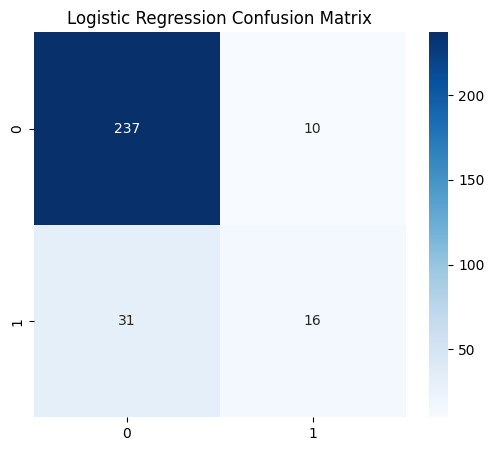

In [ ]:
# Membangun model baseline menggunakan Logistic Regression
logreg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logreg.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = logreg.predict(X_test_scaled)

print("Classification Report Baseline Logistic Regression:")
print(classification_report(
    y_test,
    y_pred_lr
))

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.show()

## Cross Validation Logistic Regression



In [ ]:


cv_lr = cross_val_score(
    logreg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print('Mean F1 Score :', cv_lr.mean())
print('Std Dev       :', cv_lr.std())

Mean F1 Score : 0.5485757467502397
Std Dev       : 0.0410780966683624


## Hyperparameter Tuning Logistic Regression


In [ ]:
param_lr = {
    'C':[0.01, 0.1, 1, 10],
    'penalty':['l2']
}

grid_lr = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_lr,
    cv=5,
    scoring='f1'
)

grid_lr.fit(
    X_train_scaled,
    y_train
)

best_lr = grid_lr.best_estimator_

print("Best Params:", grid_lr.best_params_)
print("Best Cross-Val F1 Score:", grid_lr.best_score_)

y_pred_best_lr = best_lr.predict(X_test_scaled)

print("\nClassification Report After Tuning:")
print(classification_report(
    y_test,
    y_pred_best_lr
))

Best Params: {'C': 10, 'penalty': 'l2'}
Best Cross-Val F1 Score: 0.5582039172009813

Classification Report After Tuning:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.59      0.34      0.43        47

    accuracy                           0.86       294
   macro avg       0.74      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



# Model 2 - Random Forest



Classification Report Random Forest (Baseline):
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



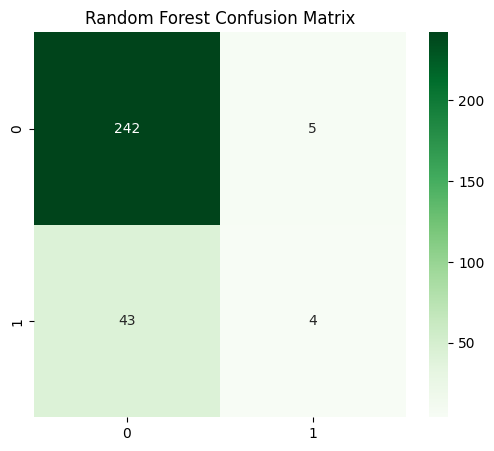

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

print("Classification Report Random Forest (Baseline):")
print(classification_report(
    y_test,
    y_pred_rf
))

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Random Forest Confusion Matrix')
plt.show()

## Cross Validation Random Forest


In [ ]:
cv_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print('Mean F1 Score :', cv_rf.mean())
print('Std Dev       :', cv_rf.std())

Mean F1 Score : 0.2075650335508778
Std Dev       : 0.0316815839946831


## Hyperparameter Tuning Random Forest

In [ ]:
# Hyperparameter Tuning Random Forest

param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("Best Params:", grid_rf.best_params_)
print("Best Cross-Val F1 Score:", grid_rf.best_score_)

y_pred_best_rf = best_rf.predict(X_test)

print("\nClassification Report Random Forest After Tuning:")
print(classification_report(
    y_test,
    y_pred_best_rf
))

Best Params: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Val F1 Score: 0.33053857906799083

Classification Report Random Forest After Tuning:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



# Model 3 - XGboost

Classification Report XGBoost (Baseline):
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.59      0.34      0.43        47

    accuracy                           0.86       294
   macro avg       0.74      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



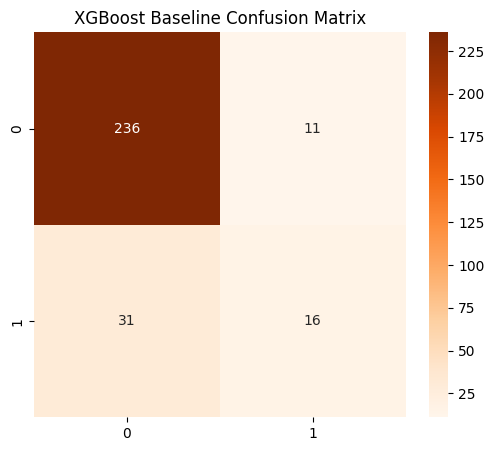

In [ ]:
# Model 3 - XGBoost Baseline
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=5
    )

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("Classification Report XGBoost (Baseline):")
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title('XGBoost Baseline Confusion Matrix')
plt.show()

## Cross Validation XGBoost

In [ ]:
# Cross Validation XGBoost
cv_xgb = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print('Mean F1 Score XGBoost (CV) :', cv_xgb.mean())
print('Std Dev XGBoost (CV)       :', cv_xgb.std())

Mean F1 Score XGBoost (CV) : 0.47825703644152384
Std Dev XGBoost (CV)       : 0.04784849709780909


## Hyperparameter Tuning XGBoost

In [ ]:
# Hyperparameter Tuning XGBoost
param_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=5),
    param_grid=param_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best Params XGBoost:", grid_xgb.best_params_)
print("Best Cross-Val F1 Score:", grid_xgb.best_score_)

# Evaluate Tuned Model
y_pred_best_xgb = best_xgb.predict(X_test)

print("\nClassification Report XGBoost After Tuning:")
print(classification_report(y_test, y_pred_best_xgb))

Best Params XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best Cross-Val F1 Score: 0.5451714088333807

Classification Report XGBoost After Tuning:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       247
           1       0.42      0.43      0.42        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.65       294
weighted avg       0.81      0.81      0.81       294



# Final Evaluation


In [ ]:
# Final Evaluation
def get_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

comparison_list = []
comparison_list.append(get_metrics('Logistic Regression', y_test, y_pred_lr))
comparison_list.append(get_metrics('Logistic Regression Tuned', y_test, y_pred_best_lr))
comparison_list.append(get_metrics('Random Forest', y_test, y_pred_rf))
comparison_list.append(get_metrics('Random Forest Tuned', y_test, y_pred_best_rf))
comparison_list.append(get_metrics('XGBoost', y_test, y_pred_xgb))
comparison_list.append(get_metrics('XGBoost Tuned', y_test, y_pred_best_xgb))

comparison_df = pd.DataFrame(comparison_list)
print("Model Comparison Table:")
comparison_df.sort_values(
    by='F1 Score',
    ascending=False
)



Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.860544,0.615385,0.340426,0.438356
1,Logistic Regression Tuned,0.857143,0.592593,0.340426,0.432432
4,XGBoost,0.857143,0.592593,0.340426,0.432432
5,XGBoost Tuned,0.812925,0.416667,0.425532,0.421053
3,Random Forest Tuned,0.833333,0.416667,0.106383,0.169492
2,Random Forest,0.836735,0.444444,0.085106,0.142857


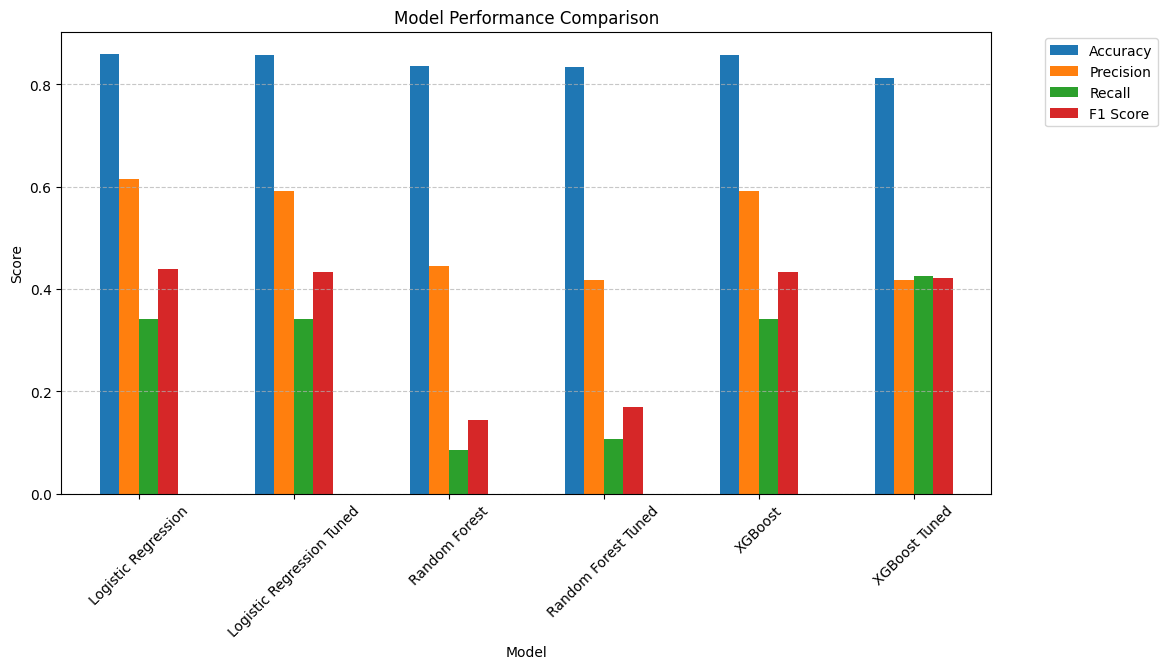

In [ ]:
# Visualisasi Perbandingan Final Evaluation
comparison_df.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Perbandingan Model Train dan Test Model

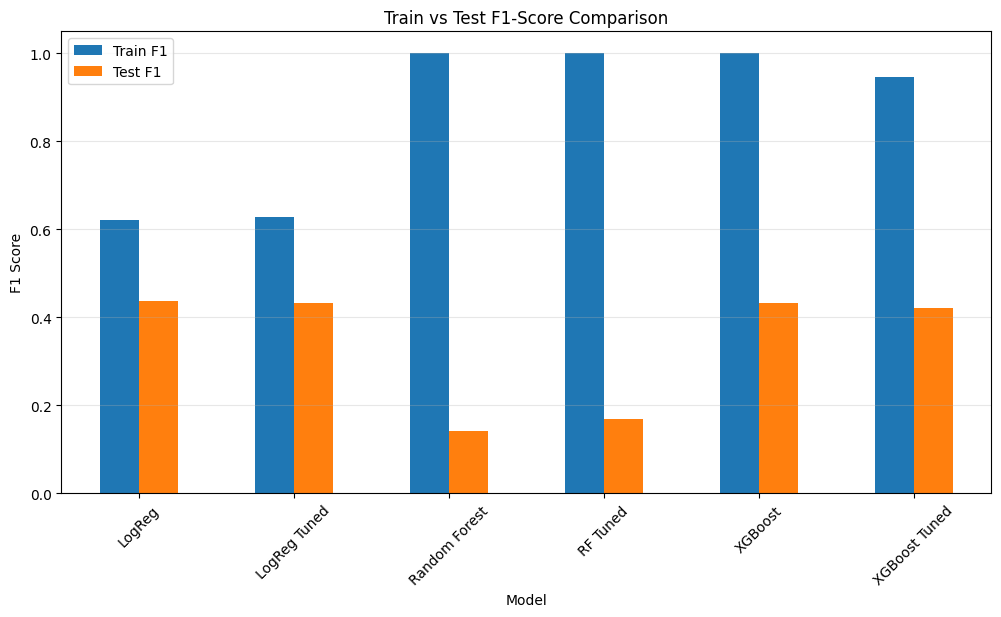

,Model,Train F1,Test F1
0,LogReg,0.620462,0.438356
1,LogReg Tuned,0.628205,0.432432
2,Random Forest,1.000000,0.142857
3,RF Tuned,1.000000,0.169492
4,XGBoost,1.000000,0.432432
5,XGBoost Tuned,0.947103,0.421053


In [ ]:
# Perbandingan Model Train dan Test Model
def get_train_test_comparison(name, model, X_train_data, y_train_data, X_test_data, y_test_data):
    y_train_pred = model.predict(X_train_data)
    y_test_pred = model.predict(X_test_data)
    return {
        'Model': name,
        'Train F1': f1_score(y_train_data, y_train_pred),
        'Test F1': f1_score(y_test_data, y_test_pred)
    }

train_test_list = []
train_test_list.append(get_train_test_comparison('LogReg', logreg, X_train_scaled, y_train, X_test_scaled, y_test))
train_test_list.append(get_train_test_comparison('LogReg Tuned', best_lr, X_train_scaled, y_train, X_test_scaled, y_test))
train_test_list.append(get_train_test_comparison('Random Forest', rf, X_train, y_train, X_test, y_test))
train_test_list.append(get_train_test_comparison('RF Tuned', best_rf, X_train, y_train, X_test, y_test))
train_test_list.append(get_train_test_comparison('XGBoost', xgb_model, X_train, y_train, X_test, y_test))
train_test_list.append(get_train_test_comparison('XGBoost Tuned', best_xgb, X_train, y_train, X_test, y_test))

train_test_df = pd.DataFrame(train_test_list)

# Visualisasi
train_test_df.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Train vs Test F1-Score Comparison')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

display(train_test_df)

# Feature Importance

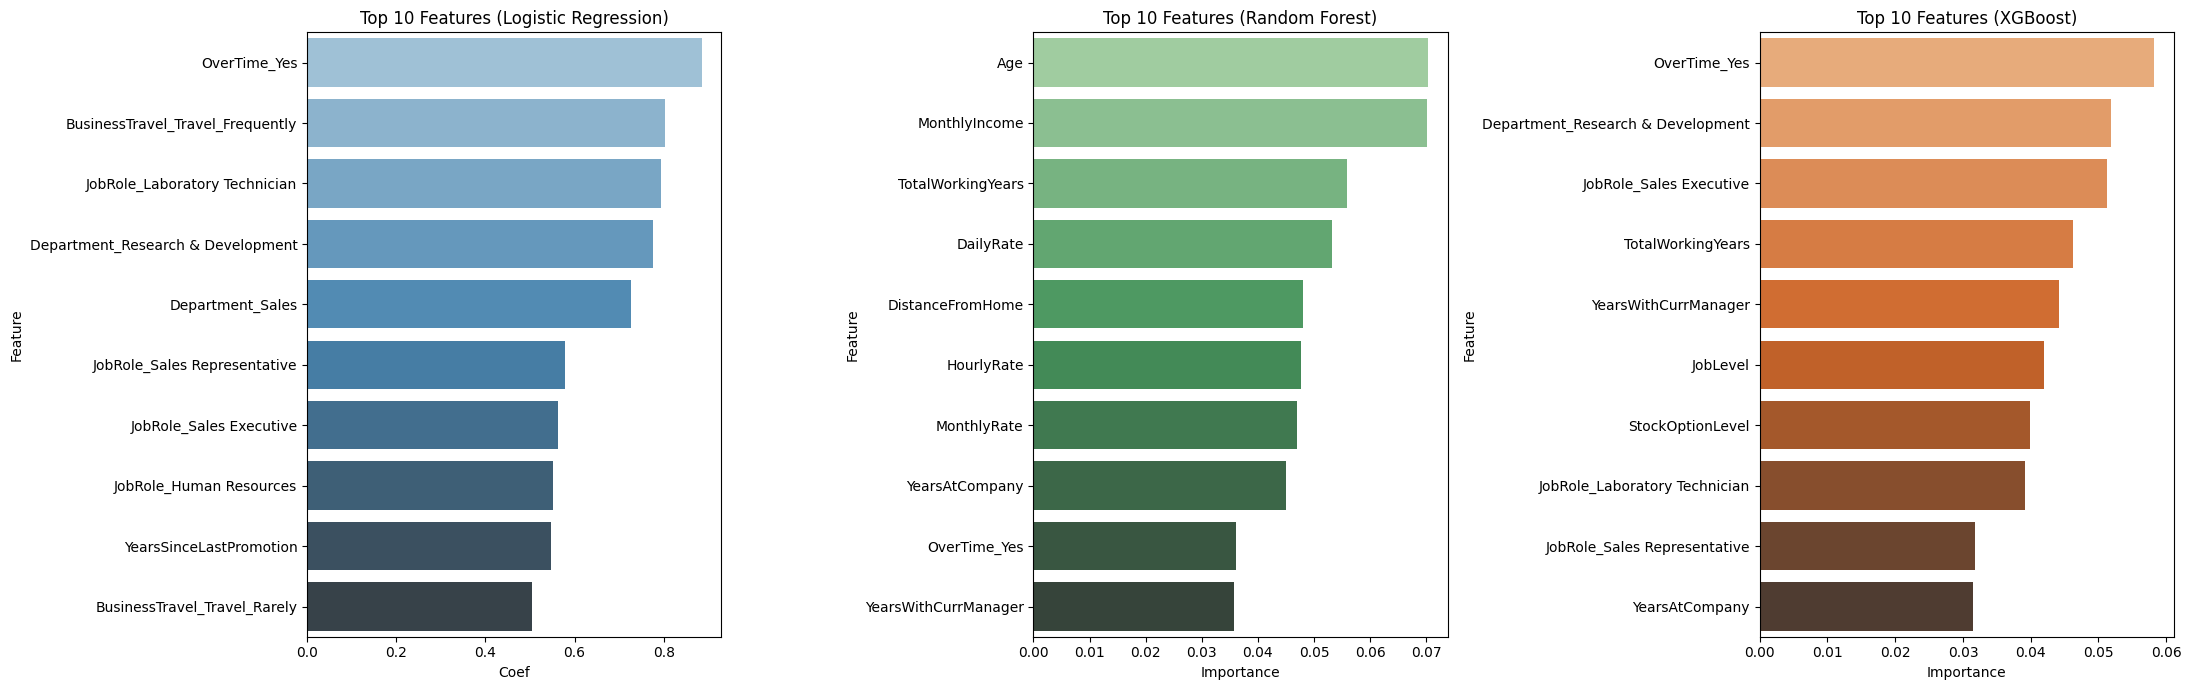

In [ ]:
plt.figure(figsize=(22, 7))

# 1. Logistic Regression Coefficients
plt.subplot(1, 3, 1)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coef': best_lr.coef_[0]})
coef_df = coef_df.sort_values('Coef', ascending=False).head(10)
sns.barplot(data=coef_df, x='Coef', y='Feature', palette='Blues_d')
plt.title('Top 10 Features (Logistic Regression)')

# 2. Random Forest Importance
plt.subplot(1, 3, 2)
rf_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': best_rf.feature_importances_})
rf_imp_df = rf_imp_df.sort_values('Importance', ascending=False).head(10)
sns.barplot(data=rf_imp_df, x='Importance', y='Feature', palette='Greens_d')
plt.title('Top 10 Features (Random Forest)')

# 3. XGBoost Importance
plt.subplot(1, 3, 3)
xgb_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': best_xgb.feature_importances_})
xgb_imp_df = xgb_imp_df.sort_values('Importance', ascending=False).head(10)
sns.barplot(data=xgb_imp_df, x='Importance', y='Feature', palette='Oranges_d')
plt.title('Top 10 Features (XGBoost)')

plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(
    {
        'best_lr': best_lr,
        'best_rf': best_rf,
        'best_xgb': best_xgb,
        'scaler': scaler,
        'feature_names': X.columns.tolist()
    },
    'mp1_artifacts.pkl'
)

df_model.to_csv(
    'employee_attrition_preprocessed.csv',
    index=False
)

## Kesimpulan Final

1. **Ranking Performa Model**:
    * Berdasarkan metrik **F1-Score** pada data testing, **Logistic Regression** dan **XGBoost** menunjukkan performa yang paling stabil dan kompetitif di kisaran ~0.43-0.44.
    * **XGBoost** memberikan hasil yang sangat baik sejak versi baseline, menunjukkan ketangguhan algoritma boosting dalam menangani data tabular.
    * **Random Forest** menunjukkan indikasi overfitting yang signifikan, terlihat dari perbedaan performa yang cukup jauh antara data training (F1=1.0) dan data testing (F1=0.14-0.17).

2. **Analisis Fitur Kunci**:
    * Fitur **OverTime** secara konsisten menjadi prediktor terkuat dalam semua model. Karyawan yang sering lembur memiliki probabilitas attrition yang jauh lebih tinggi.
    * Faktor finansial (**MonthlyIncome**) dan kematangan karier (**Age**, **TotalWorkingYears**) juga memegang peranan krusial dalam keputusan karyawan untuk bertahan.

3. **Catatan Data Imbalance**:
    * Adanya ketimpangan kelas (hanya ~16% Attrition) menjadi tantangan utama. Penggunaan `scale_pos_weight` dan `class_weight` telah membantu model untuk lebih sensitif terhadap kelas minoritas, namun perbaikan lebih lanjut mungkin memerlukan teknik sampling tambahan atau penambahan fitur baru.

## Rekomendasi Bisnis

1. **Optimalisasi Beban Kerja**: Meninjau kembali kebijakan lembur (Overtime) karena ini adalah pemicu utama attrition. Perusahaan perlu memastikan beban kerja terdistribusi dengan adil atau memberikan kompensasi yang sepadan untuk mencegah *burnout*.

2. **Program Retensi Terpilih**: Fokus pada kelompok karyawan dengan pendapatan di bawah rata-rata atau karyawan muda yang memiliki masa kerja singkat melalui program pengembangan karier yang lebih terstruktur.

3. **Intervensi Berbasis Peran**: Memberikan perhatian khusus pada departemen Sales dan peran Laboratory Technician, yang menunjukkan pola attrition lebih tinggi dibandingkan peran manajerial.

4. **Pemantauan Kontinu**: Mengintegrasikan model ini ke dalam sistem HR untuk memberikan peringatan dini (*early warning*) terhadap karyawan yang menunjukkan profil risiko tinggi sehingga langkah preventif dapat diambil lebih awal.